The objective of this notebook is to load the Bank Account Fraud (BAF) dataset, understand its structure, inspect data quality, identify missing values and duplicates, analyze data types, and perform an initial exploration before preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
PROJECT_DIR = Path.cwd().parent
DATA_PATH = PROJECT_DIR / "data" / "raw" / "Base.csv"
print(DATA_PATH)

c:\Users\dell\OneDrive\Desktop\Financial-Fraud-Detection\data\raw\Base.csv


In [4]:
df = pd.read_csv(DATA_PATH)
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [15]:
rows, cols = df.shape
print("DATASET SHAPE")
print(f"Rows    : {rows:,}")
print(f"Columns : {cols}")

DATASET SHAPE
Rows    : 1,000,000
Columns : 32


In [16]:
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [17]:
df.tail()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
999995,0,0.8,0.124690,-1,143,30,0.051348,-0.826239,AB,530,6732.602414,3010.048099,3095.754245,42,8,CA,305,1,BB,1,1,31,0,1500.0,0,INTERNET,16.967770,other,0,1,0,7
999996,0,0.9,0.824544,-1,193,30,0.009591,0.008307,AC,408,1574.293294,2716.495767,4286.089050,0,5,CA,235,0,BA,1,1,-1,1,1000.0,0,INTERNET,1.504109,macintosh,0,1,0,7
999997,0,0.8,0.140891,-1,202,10,0.059287,50.609995,AA,749,1258.864938,3601.322892,3103.891664,2,3,CA,195,1,BE,0,1,31,0,200.0,0,INTERNET,16.068595,other,0,1,0,7
999998,0,0.9,0.002480,52,3,30,0.023357,-1.313387,AB,707,7048.137128,6521.395012,3068.265084,7,8,CA,148,0,BD,0,1,1,0,200.0,0,INTERNET,1.378683,linux,1,1,0,7
999999,0,0.6,0.993391,-1,174,30,0.020422,14.942456,AA,655,3737.076479,3135.788094,3051.003293,14,8,CA,100,1,BB,0,1,15,1,200.0,0,INTERNET,1.947926,other,1,1,0,7


In [18]:
df.sample(5, random_state=42)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
987231,0,0.1,0.218119,110,7,20,0.015684,-1.013463,AD,687,1442.159111,6438.768228,3060.149789,9,2,CE,172,0,BE,0,1,28,0,500.0,0,INTERNET,15.611467,windows,1,1,0,7
79954,0,0.1,0.373086,29,7,20,0.024277,19.342285,AA,1230,6236.294791,5484.355709,4760.177409,706,9,CB,128,1,BC,0,1,22,0,200.0,0,INTERNET,5.911984,other,0,1,0,0
567130,0,0.2,0.515218,-1,64,20,0.015865,-1.333985,AB,2045,5302.674495,5521.168702,4970.617404,14,16,CA,7,1,BE,1,1,25,1,200.0,0,INTERNET,4.732999,other,1,1,0,4
500891,0,0.6,0.899345,-1,56,20,0.018821,-1.524424,AC,1260,5401.796610,4411.629738,4831.579015,1,13,CA,96,1,BC,0,1,-1,0,200.0,0,INTERNET,8.210518,linux,1,1,0,3
55399,0,0.9,0.794648,-1,64,50,0.027359,-1.254528,AB,1643,10657.943300,6073.103673,6376.081608,13,7,CB,85,0,BC,0,1,1,0,200.0,0,INTERNET,5.131610,other,0,1,0,0


In [8]:
print("Columns Present in Dataset\n")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Columns Present in Dataset

1. fraud_bool
2. income
3. name_email_similarity
4. prev_address_months_count
5. current_address_months_count
6. customer_age
7. days_since_request
8. intended_balcon_amount
9. payment_type
10. zip_count_4w
11. velocity_6h
12. velocity_24h
13. velocity_4w
14. bank_branch_count_8w
15. date_of_birth_distinct_emails_4w
16. employment_status
17. credit_risk_score
18. email_is_free
19. housing_status
20. phone_home_valid
21. phone_mobile_valid
22. bank_months_count
23. has_other_cards
24. proposed_credit_limit
25. foreign_request
26. source
27. session_length_in_minutes
28. device_os
29. keep_alive_session
30. device_distinct_emails_8w
31. device_fraud_count
32. month


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  str    
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000000 non-nul

In [10]:
memory = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Dataset Memory Usage : {memory:.2f} MB")

Dataset Memory Usage : 458.45 MB


In [11]:
datatype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})
datatype_summary

,Column,Data Type
0,fraud_bool,int64
1,income,float64
2,name_email_similarity,float64
3,prev_address_months_count,int64
4,current_address_months_count,int64
5,customer_age,int64
6,days_since_request,float64
7,intended_balcon_amount,float64
8,payment_type,str
9,zip_count_4w,int64


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,16.718568,44.046230,-1.000000e+00,-1.000000,-1.000000,12.000000,383.000000
current_address_months_count,1000000.0,86.587867,88.406599,-1.000000e+00,19.000000,52.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


In [13]:
df.describe(include="object").T

,count,unique,top,freq
payment_type,1000000,5,AB,370554
employment_status,1000000,7,CA,730252
housing_status,1000000,7,BC,372143
source,1000000,2,INTERNET,992952
device_os,1000000,5,other,342728


In [19]:
missing_values = pd.DataFrame({"Missing Values": df.isnull().sum(),
                               "Percentage": (df.isnull().sum() / len(df)) * 100})
missing_values.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
fraud_bool,0,0.0
income,0,0.0
name_email_similarity,0,0.0
prev_address_months_count,0,0.0
current_address_months_count,0,0.0
customer_age,0,0.0
days_since_request,0,0.0
intended_balcon_amount,0,0.0
payment_type,0,0.0
zip_count_4w,0,0.0


In [20]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [21]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

unique_values

,Column,Unique Values
0,fraud_bool,2
1,income,9
2,name_email_similarity,998861
3,prev_address_months_count,374
4,current_address_months_count,423
5,customer_age,9
6,days_since_request,989330
7,intended_balcon_amount,994971
8,payment_type,5
9,zip_count_4w,6306


In [22]:
df["fraud_bool"].value_counts()

fraud_bool
0    988971
1     11029
Name: count, dtype: int64

In [23]:
fraud_percent = (df["fraud_bool"].value_counts(normalize=True).mul(100).round(2))
fraud_percent

fraud_bool
0    98.9
1     1.1
Name: proportion, dtype: float64

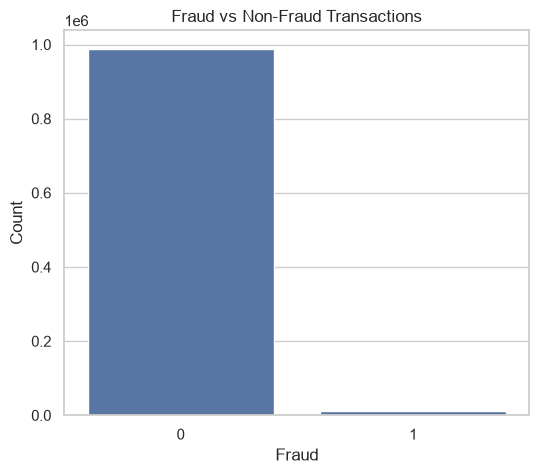

In [24]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x="fraud_bool")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

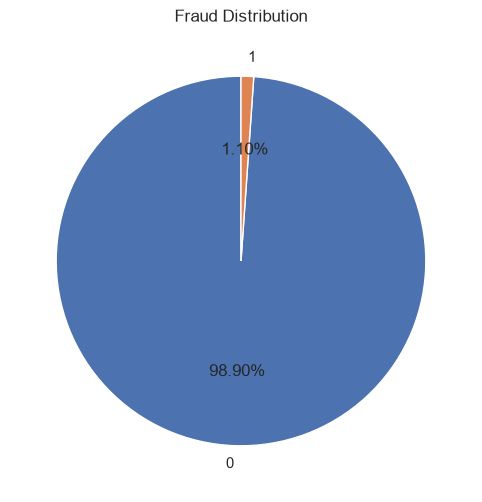

In [25]:
plt.figure(figsize=(6,6))
df["fraud_bool"].value_counts().plot(kind="pie",autopct="%1.2f%%",startangle=90)
plt.ylabel("")
plt.title("Fraud Distribution")
plt.show()

In [26]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns
categorical_columns = df.select_dtypes(include=["object","string"]).columns
print("Numerical Features :", len(numerical_columns))
print("Categorical Features :", len(categorical_columns))

Numerical Features : 27
Categorical Features : 5


In [ ]:
print("Numerical Columns")
for col in numerical_columns:
    print(col)
print("\n")
print("Categorical Columns")
for col in categorical_columns:
    print(col)

Numerical Columns
fraud_bool
income
name_email_similarity
prev_address_months_count
current_address_months_count
customer_age
days_since_request
intended_balcon_amount
zip_count_4w
velocity_6h
velocity_24h
velocity_4w
bank_branch_count_8w
date_of_birth_distinct_emails_4w
credit_risk_score
email_is_free
phone_home_valid
phone_mobile_valid
bank_months_count
has_other_cards
proposed_credit_limit
foreign_request
session_length_in_minutes
keep_alive_session
device_distinct_emails_8w
device_fraud_count
month


Categorical Columns
payment_type
employment_status
housing_status
source
device_os


In [28]:
from pathlib import Path
processed_path = PROJECT_DIR / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)
df.to_csv(processed_path / "fraud_loaded.csv",index=False)
print("Dataset saved successfully.")

Dataset saved successfully.


# Conclusion
- Successfully loaded the Bank Account Fraud (BAF) dataset.
- The dataset contains **1,000,000 rows** and **32 features**.
- No missing values were found.
- Data types include numerical and categorical variables.
- Initial fraud distribution indicates a highly imbalanced dataset.
- The dataset has been saved as `fraud_loaded.csv` for subsequent preprocessing.
